## 1. Contexte 
L'équipe de stratégie de tarification a obtenu un budget supplémentaire de 2 millions de dollars pour le premier trimestre 2025 afin d'offrir des réductions aux clients sur des segments ciblés dans le secteur de l'hôtellerie.  

## 2. Objectif du projet  
**L’objectif de ce projet est d’optimiser l’allocation d’un budget de 2 millions de dollars destiné aux remises dans le secteur hôtelier, afin de maximiser la valeur des réservations.**

L'équipe a sélectionné les dimensions suivantes pour l'optimisation : **super-région hôtelière**, **type d'appareil** et **classification par étoiles des hôtels**.

## 3. Dictionnaire 
| Variables              | Description                                                                 | 
|----------------------|-----------------------------------------------------------------------------|
| Spend                |Remise tarifaire offerte aux clients à une date donnée, pour une super-région,   un type d'appareil et une catégorie d'étoiles d'hôtel (en USD)           | 
| NBV A                | Valeur totale des réservations générée à une date donnée, pour une super-région, un type d'appareil et une catégorie d'étoiles d'hôtel, dans le groupe de test de tarification A (en USD).    |                       
| NBV B                | Valeur totale des réservations (groupe de test B)    |                      
| Date                 | Date des métriques (données journalières)            |                   
| Hotel Super region   | Localisation géographique de l'hôtel réservé         |                      
| Device               | Type d'appareil utilisé pour la réservation          |                    
| StarRating           | Catégorie d'étoiles de l'hôtel                       |                    

Dictionnaire des données   

- **Hotel Super region** : Localisation de l'hôtel réservé.
    + NORAM = Amérique du Nord
    + LATAM = Amérique du Sud et Amérique Centrale
    + APAC = Asie & Pacifique
    + EMEA = Europe et Moyen-Orient
- **Device** : Type d'appareil (mobile ou ordinateur) utilisé pour réserver l'hôtel.
- **StarRating** : Catégorie d'étoiles de l'hôtel réservé.  
   • Low : hôtels économiques (1 à 2 étoiles)   
   • Mid : hôtels de milieu de gamme (3 étoiles)  
   • High : hôtels haut de gamme ou de luxe (4 à 5 étoiles)

**Informations supplementaire**  
L’équipe de tarification évalue la performance des programmes de réduction grâce à un groupe témoin constant (30 % du trafic) sur lequel aucune remise n’est appliquée ("groupe A").
Au cours du quatrième trimestre (Q4), l’équipe a progressivement augmenté les dépenses sur l’ensemble des segments d’environ 10 %.

## Import 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler

from pathlib import Path


In [10]:
root = Path().resolve().parent/"data"
data = pd.read_excel(root/"Pricing.xlsx",)
df = data.copy()

## Aperçu des données 

In [11]:
df.head()

,date,HotelSuperRegion,Device,StarRating,spend,NBV A,NBV B
0,2024-10-12,NORAM,Desktop,High,12608,337183,820891
1,2024-10-18,APAC,Desktop,Mid,5513,34517,100962
2,2024-11-10,APAC,Desktop,Mid,6105,38275,101472
3,2024-12-20,APAC,Desktop,Mid,6154,36723,102143
4,2024-12-14,APAC,Mobile,High,7819,4638900,13218600


## Analyse exploratoire de données 

In [15]:
print("Nombre de valeurs manquantes par variable")
display(df.isna().sum())
print("Nombre de valeurs Null par variable")
display(df.isnull().sum())

Nombre de valeurs manquantes par variable


date                0
HotelSuperRegion    0
Device              0
StarRating          0
spend               0
NBV A               0
NBV B               0
dtype: int64

Nombre de valeurs Null par variable


date                0
HotelSuperRegion    0
Device              0
StarRating          0
spend               0
NBV A               0
NBV B               0
dtype: int64

### Statistiques univariées

 
* Remise tarifaire offert aux client 

In [16]:
import sys
sys.path.append('..')
from src.visualisation import univ_analysis_discrete, univ_analysis_continue


/----spend----/


count     2208.000000
mean     10490.623188
std       2918.857616
min       3058.000000
25%       8218.750000
50%      11114.500000
75%      12500.750000
max      16522.000000
Name: spend, dtype: float64

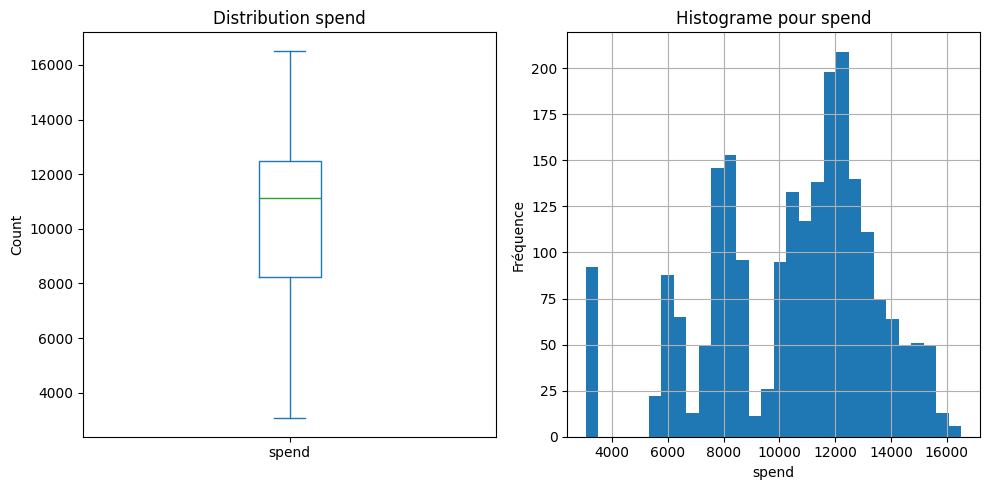

In [17]:
univ_analysis_continue(df, "spend")

La Remise tarifaire moyen offerte aux clients à une date donnée, pour une super-région, un type d'appareil et une catégorie d'étoiles d'hôtel (en USD) est de ~10500 avec un ecart type de ~3000 USD

### Statistique bivariée 

**Distribution des Remises tarifaires par**:
- region
- catégorie d'etoile
- Type d'appareil 

In [25]:
display(df.groupby("HotelSuperRegion")["NBV A"].describe())

,count,mean,std,min,25%,50%,75%,max
HotelSuperRegion,,,,,,,,
APAC,552.0,2.406065e+06,3.573756e+06,19133.0,36416.00,43137.5,4643675.00,9345100.0
EMEA,552.0,1.195246e+05,1.672044e+04,94135.0,101753.25,121378.5,124806.25,156603.0
LATAM,552.0,1.343793e+05,2.319524e+04,97260.0,105867.75,142749.0,149404.00,172485.0
NORAM,552.0,3.277795e+05,2.532074e+04,279919.0,310084.25,326630.5,343700.25,385288.0


======== Distribution des remises tarifaires par region, catégorie d'etoile et type d'appareil ===========


,count,mean,std,min,25%,50%,75%,max
HotelSuperRegion,,,,,,,,
APAC,552.0,8598.050725,4238.057739,3058.0,5930.75,6909.5,13623.75,16221.0
EMEA,552.0,9966.414855,1484.968745,7535.0,8487.50,10132.0,10684.00,13846.0
LATAM,552.0,10593.250000,1771.989624,7340.0,8528.75,11257.5,12087.50,13252.0
NORAM,552.0,12804.777174,1256.936641,10701.0,11862.75,12519.5,13523.50,16522.0


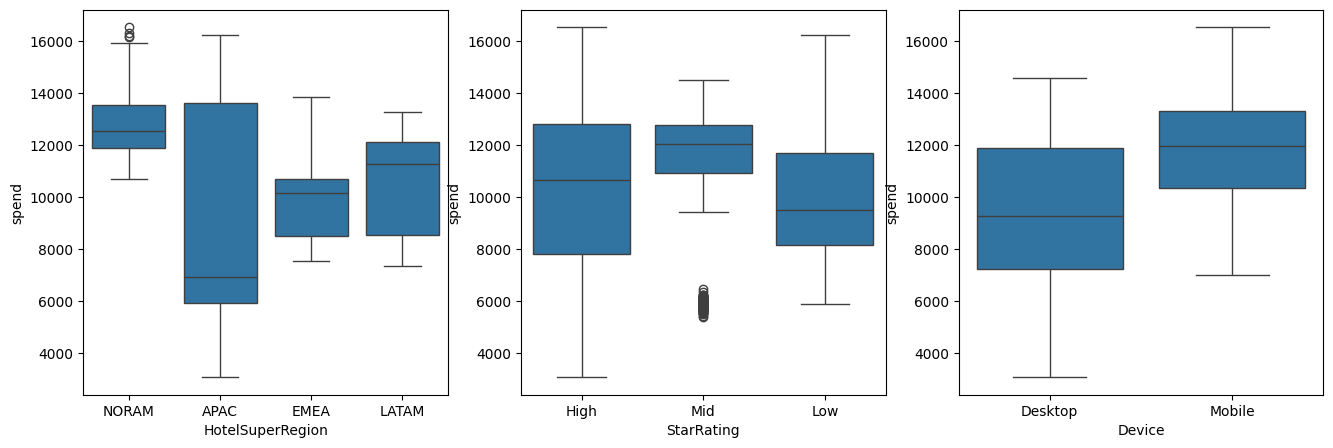

In [24]:
print("======== Distribution des remises tarifaires par region, catégorie d'etoile et type d'appareil ===========")
display(df.groupby("HotelSuperRegion")['spend'].describe())
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16,5))

sns.boxplot(data=df, y="spend",x="HotelSuperRegion",ax=ax[0])
sns.boxplot(data=df, y="spend",x="StarRating",ax=ax[1])
sns.boxplot(data=df, y="spend",x="Device",ax=ax[2])
plt.show()

* Par région (1er boxplot)
   - NORAM a la mediane la plus haute (~12 500$) avec peu de variablité. Il est la région où le budget est déployé de façon la plus régulière et la plus intensive — le spend journalier est élevé et stable. C'est la région la plus "mature" en termes de programme de remises. 

   - APAC a une boîte très large et une médiane basse (~6 500$) → spend très variable selon les jours, parfois très faible. APAC montre un spend très irrégulier avec des journées quasi sans investissement.
* Par étoiles 
   - Mid a la médiane la plus haute et la boîte la plus serrée → spend le plus stable. Les outliers bas sur Mid (~5 800$) méritent investigation : Est-ce des jours sans campagne ?

* Par device 
    - Mobile et Desktop ont des distributions très proches en médiane (~12 000$)

## Création des KPIs 

1. Un KPI pertinent pour mesurer l'incrementality
- Un KPI pertinent pour mesurer l'incrementality($) généré par la tarification est défini par la difference de valeur des réservation générée entre le groupe de test et le groupe témoin (`NBV A`) 

In [7]:
df["Incrementality"] = df["NBV B"] - df["NBV A"]

2. KPI pertinent pour mesurer l’efficacité
* RoS : Un KPI pertinent pour mesurer l’efficacité des dépenses est le return on spend : qui évalue combien de dollars de valeur de réservation sont générés pour chaque dollar investi dans les réductions.
* Pour 1$ de remise offert, combien de dollars de réservations supplémentaires est-ce que je génère ?"

In [8]:
df["Spend_Efficiency"] = df["Incrementality"]/df["spend"]

## Clustering 

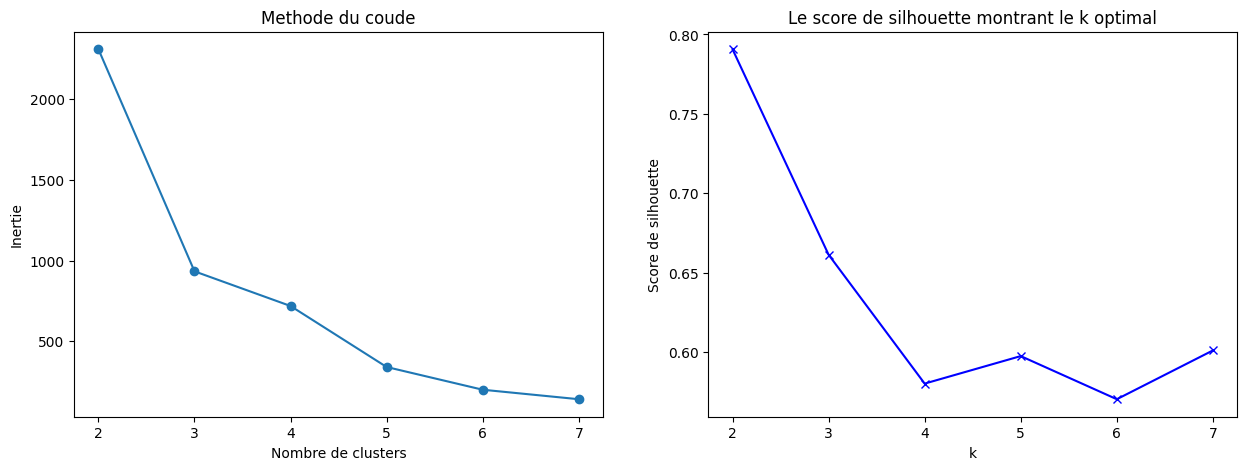

In [9]:
clustring_data = df[["spend","Incrementality", "Spend_Efficiency"]]

scaler = StandardScaler()
X = scaler.fit_transform(clustring_data)

inertias = []
silhouette = []
k_liste = range(2,8)
for k in k_liste:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouette.append(silhouette_score(X, km.labels_))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
axes[0].plot(k_liste, inertias, marker='o')
axes[0].set_xlabel("Nombre de clusters")
axes[0].set_ylabel("Inertie")
axes[0].set_title("Methode du coude")


# Courbe de la methode de silhouette
axes[1].plot(k_liste, silhouette, 'bx-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score de silhouette')
axes[1].set_title('Le score de silhouette montrant le k optimal')
plt.show()

Les deux graphiques pointent vers k=3
- `Méthode du coude ` Le coude le plus marqué se situe à k = 3, où la courbe d'inertie change nettement de pente (de 2300 à ~950), avant de s'aplatir progressivement.

- `Score de silhouette` Le score est clairement le plus élevé à k = 2 (~0.79), puis chute fortement.. Un score proche de 1 indique des clusters très bien **séparés** et **coherent**.

- `Conclusion`   
k = 2 est le choix le plus objectivement justifié par le score de silhouette, mais nous préferons k = 3 pour un compromis structure/compacité. Pour plus de granularité sur nos analyses 

In [10]:
kmeans = KMeans(n_clusters=3, n_init=10)
labels = kmeans.fit_predict(X)

* Ajout de label dans le dataset 

In [11]:
df["Cluster"]=labels

df_cluster_segment = df.groupby(["Cluster","HotelSuperRegion","Device", "StarRating"]).agg(
    total_spend = ("spend", "sum"),
    total_Incrementality = ("Incrementality","mean"), 
    mean_SpendEfficiency = ("Spend_Efficiency","mean")
    
).reset_index()

* on va trier par mean_SpendEfficiency : la moyenne des ratios journaliers

In [12]:
df_cluster_segment = df_cluster_segment.sort_values(by="mean_SpendEfficiency", ascending=False).head(20)
df_cluster_segment["segment"] = df_cluster_segment["HotelSuperRegion"]+'-'+ df_cluster_segment["Device"] +'-'+df_cluster_segment["StarRating"]
display(df_cluster_segment)

,Cluster,HotelSuperRegion,Device,StarRating,total_spend,total_Incrementality,mean_SpendEfficiency,segment
27,2,APAC,Mobile,Mid,828720,1.555681e+07,1126.970981,APAC-Mobile-Mid
26,2,APAC,Mobile,Low,910140,1.700044e+07,1121.461600,APAC-Mobile-Low
25,2,APAC,Mobile,High,460882,8.601698e+06,1120.354371,APAC-Mobile-High
14,0,NORAM,Mobile,Low,1096388,4.531451e+05,38.073177,NORAM-Mobile-Low
15,0,NORAM,Mobile,Mid,1190549,4.807897e+05,37.193941,NORAM-Mobile-Mid
12,0,NORAM,Desktop,Mid,1111186,4.422154e+05,36.659310,NORAM-Desktop-Mid
11,0,NORAM,Desktop,Low,1058603,4.178563e+05,36.356663,NORAM-Desktop-Low
10,0,NORAM,Desktop,High,1231047,4.811774e+05,36.003573,NORAM-Desktop-High
13,0,NORAM,Mobile,High,1380464,5.242271e+05,34.984211,NORAM-Mobile-High
22,1,EMEA,Desktop,Mid,9430,1.926560e+05,20.430117,EMEA-Desktop-Mid
